## Data Preprocessing

In [1]:
library(phyloseq)
library(biomformat)
library(ggplot2)
library(vegan)
library(limma)
library(edgeR)
library(pheatmap)
library(DESeq2)
library(ggpubr)

Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:biomformat’:

    colnames, rownames


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked 

In [2]:

# Step 1: Import Data and Preprocess Sample Names
# Import the BIOM file to create a phyloseq object
biom_file <- "/home/gamorten/Microbiome_Health/data/table_kreport_only.biom"
physeq <- import_biom(biom_file)

# Clean sample names to extract only the part before the first underscore
sample_names(physeq) <- unlist(lapply(sample_names(physeq), function(x) sub("_.*", "", x)))

# Load sample metadata and merge with the phyloseq object
sample_metadata <- read.csv("/home/gamorten/Microbiome_Health/metadata/metadata.csv", header = TRUE, row.names = 1)
sample_data_ps <- sample_data(sample_metadata)
physeq <- merge_phyloseq(physeq, sample_data_ps)

#Make batch a factor for quality control
sample_data(physeq)$Batch <- as.factor(sample_data(physeq)$Batch)

# Rename tax table columns to be informative
tax_table_df <- as.data.frame(tax_table(physeq))
colnames(tax_table_df) <- c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")
tax_table(physeq) <- tax_table(as.matrix(tax_table_df))

# Prune samples where there are less than 1000 reads
physeq <- prune_samples(sample_sums(physeq) >= 1000, physeq)

# Filter out low-abundance taxa with 10% threshhold
physeq_filtered <- filter_taxa(physeq, function(x) sum(x > 0) > (0.1 * length(x)), TRUE)

# Prune any taxa with NA names
physeq_filtered <- subset_taxa(physeq, !apply(tax_table(physeq), 1, function(row) {
  any(is.na(row) | row == "")
}))

print(physeq_filtered)


Warning message in strsplit(conditionMessage(e), "\n"):
“unable to translate 'lexical error: invalid char in json text.
                                       <89>HDF                        (right here) ------^
' to a wide string”
Warning message in strsplit(conditionMessage(e), "\n"):
“input string 1 is invalid”


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 16599 taxa and 73 samples ]
sample_data() Sample Data:       [ 73 samples by 23 sample variables ]
tax_table()   Taxonomy Table:    [ 16599 taxa by 7 taxonomic ranks ]


In [3]:
# Convert taxonomic table to a data frame
tax_table_df <- as.data.frame(tax_table(physeq_filtered))

# Convert OTU table to a data frame
otu_table_df <- as.data.frame(otu_table(physeq_filtered))

# Convert sample metadata to a data frame
sample_metadata_df <- as.data.frame(sample_data(physeq_filtered))

# Print the first few rows to verify
print(head(tax_table_df))
print(head(otu_table_df))
print(head(sample_metadata_df))


           Kingdom          Phylum          Class            Order
171549 k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
815    k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
816    k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
820    k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
28111  k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
46506  k__Bacteria p__Bacteroidota c__Bacteroidia o__Bacteroidales
                  Family          Genus      Species
171549               f__            g__          s__
815    f__Bacteroidaceae            g__          s__
816    f__Bacteroidaceae g__Bacteroides          s__
820    f__Bacteroidaceae g__Bacteroides s__uniformis
28111  f__Bacteroidaceae g__Bacteroides s__eggerthii
46506  f__Bacteroidaceae g__Bacteroides s__stercoris
       S00JD-0019 S00JD-0015 S00JD-0013 S00NO-0023 S00JD-0002 S00JD-0001
171549     208938     240778     108335     791008     397489     264862
815         56

In [4]:
# Check for NA values in the taxonomic table
na_count_tax <- sum(is.na(tax_table_df))
print(paste("Number of NA values in the taxonomic table:", na_count_tax))

# Check for NA values column-wise
na_by_column_tax <- colSums(is.na(tax_table_df))
print("Number of NA values in each column of the taxonomic table:")
print(na_by_column_tax)


[1] "Number of NA values in the taxonomic table: 0"
[1] "Number of NA values in each column of the taxonomic table:"
Kingdom  Phylum   Class   Order  Family   Genus Species 
      0       0       0       0       0       0       0 


In [5]:
# Check basic statistics of OTU table
library(dplyr)

# Total counts per sample
otu_sample_sums <- sample_sums(physeq_filtered)
print("Total counts per sample:")
print(summary(otu_sample_sums))

# Total counts per taxon
otu_taxa_sums <- taxa_sums(physeq_filtered)
print("Total counts per taxon:")
print(summary(otu_taxa_sums))

# Summary statistics of the OTU table
print("Summary of OTU table:")
otu_summary <- otu_table_df %>%
  summarise(across(everything(), list(mean = mean, sd = sd, min = min, max = max)))
print(otu_summary)



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union




The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Total counts per sample:"
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
  282627  4632164  6216377  9598651 15184850 27958844 
[1] "Total counts per taxon:"
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
       1       34      754    42213     2357 50581045 
[1] "Summary of OTU table:"
  S00JD-0019_mean S00JD-0019_sd S00JD-0019_min S00JD-0019_max S00JD-0015_mean
1        250.5891      6983.161              0         632079        308.6309
  S00JD-0015_sd S00JD-0015_min S00JD-0015_max S00JD-0013_mean S00JD-0013_sd
1      10586.74              0        1018176        197.9946      3869.739
  S00JD-0013_min S00JD-0013_max S00NO-0023_mean S00NO-0023_sd S00NO-0023_min
1              0         226201        1262.205      25371.17              0
  S00NO-0023_max S00JD-0002_mean S00JD-0002_sd S00JD-0002_min S00JD-0002_max
1        1640135        397.9894      10930.57              0         861601
  S00JD-0001_mean S00JD-0001_sd S00JD-0001_min S00JD-0001_max S00JD-0008_me

In [6]:
## Inspect and prepare metadata
md <- as.data.frame(sample_data(physeq_filtered))

# Check labels
table(md$Hypertension, useNA = "ifany")
table(md$GDM, useNA = "ifany")

# Standardize as factors (optional but recommended)
md$Hypertension <- factor(md$Hypertension, levels = c("No", "Yes"))
md$GDM          <- factor(md$GDM, levels = c("No", "Yes"))

sample_data(physeq_filtered) <- sample_data(md)

## -------------------------
## Control vs GH
## -------------------------

physeq_GH <- subset_samples(
  physeq_filtered,
  Hypertension == "Yes" | (Hypertension == "No" & GDM == "No")
)

# Create grouping variable
md_GH <- as.data.frame(sample_data(physeq_GH))
md_GH$Group_GH <- ifelse(md_GH$Hypertension == "Yes", "GH", "Control")
md_GH$Group_GH <- factor(md_GH$Group_GH, levels = c("Control", "GH"))
sample_data(physeq_GH) <- sample_data(md_GH)

# Sanity check
table(md_GH$Group_GH)


## -------------------------
## Control vs GDM
## -------------------------

physeq_GDM <- subset_samples(
  physeq_filtered,
  GDM == "Yes" | (Hypertension == "No" & GDM == "No")
)

# Create grouping variable
md_GDM <- as.data.frame(sample_data(physeq_GDM))
md_GDM$Group_GDM <- ifelse(md_GDM$GDM == "Yes", "GDM", "Control")
md_GDM$Group_GDM <- factor(md_GDM$Group_GDM, levels = c("Control", "GDM"))
sample_data(physeq_GDM) <- sample_data(md_GDM)

# Sanity check
table(md_GDM$Group_GDM)



     No Yes 
  1  37  35 


     No Yes 
  1  54  18 


Control      GH 
     31      35 


Control     GDM 
     31      18 

## Quality Control

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message in scale_fill_gradient(low = low, high = high, trans = trans, na.value = na.value):
“log-4 transformation introduced infinite values.”


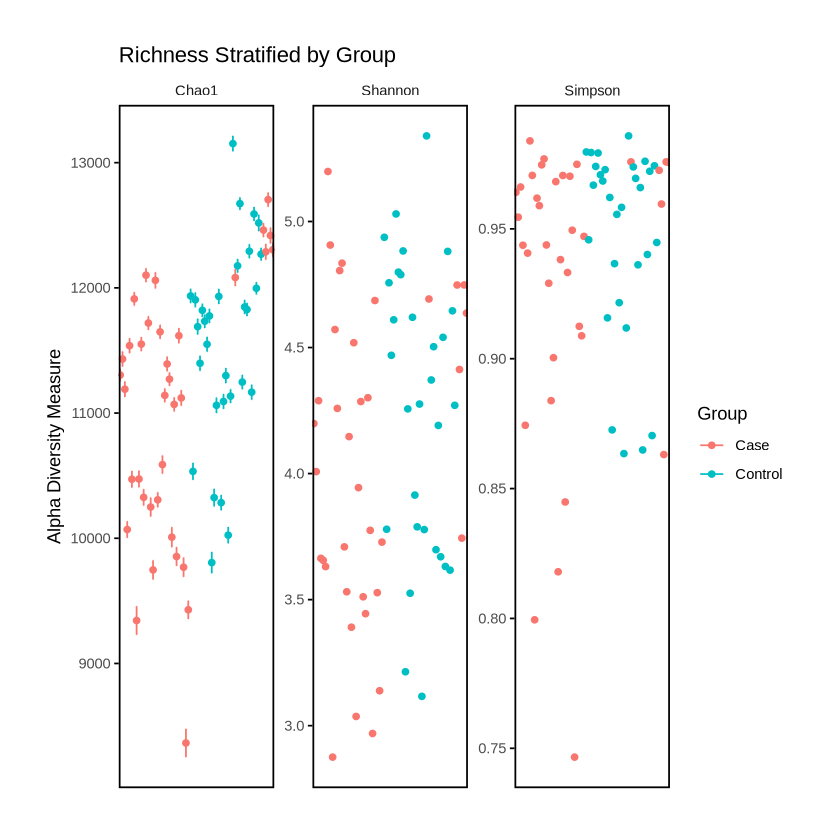

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


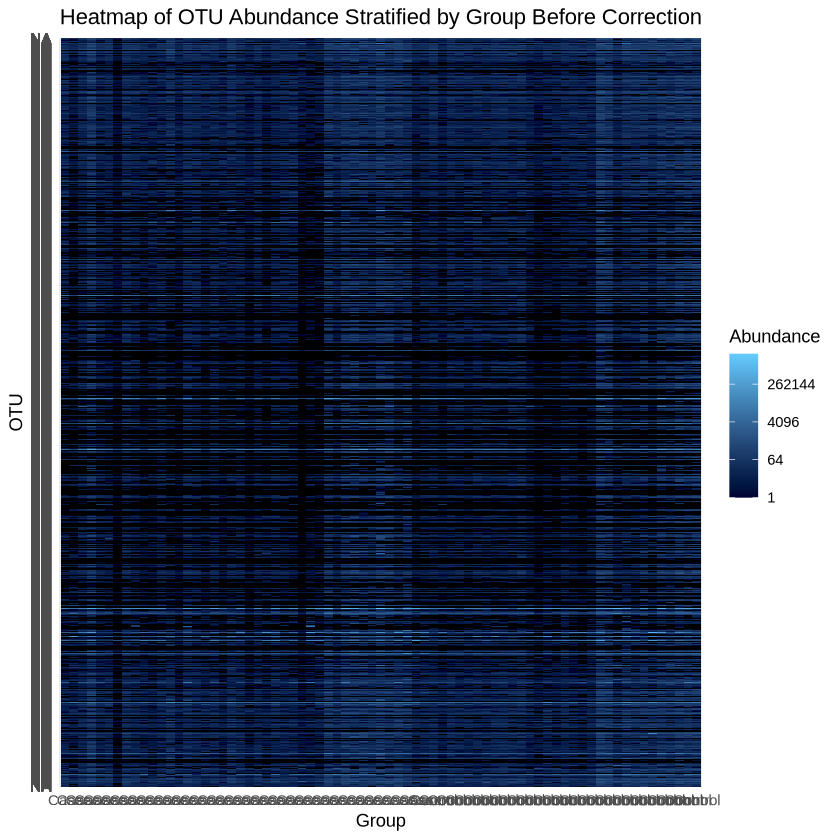

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1565921 
Run 1 stress 0.1602799 
Run 2 stress 0.1622272 
Run 3 stress 0.1637497 
Run 4 stress 0.169426 
Run 5 stress 0.1605533 
Run 6 stress 0.1626226 
Run 7 stress 0.1609737 
Run 8 stress 0.1626286 
Run 9 stress 0.1625443 
Run 10 stress 0.1635514 
Run 11 stress 0.1619892 
Run 12 stress 0.1628835 
Run 13 stress 0.17093 
Run 14 stress 0.16264 
Run 15 stress 0.1679085 
Run 16 stress 0.1632559 
Run 17 stress 0.1661842 
Run 18 stress 0.1657356 
Run 19 stress 0.1629147 
Run 20 stress 0.166159 
*** Best solution was not repeated -- monoMDS stopping criteria:
     1: no. of iterations >= maxit
    18: stress ratio > sratmax
     1: scale factor of the gradient < sfgrmin


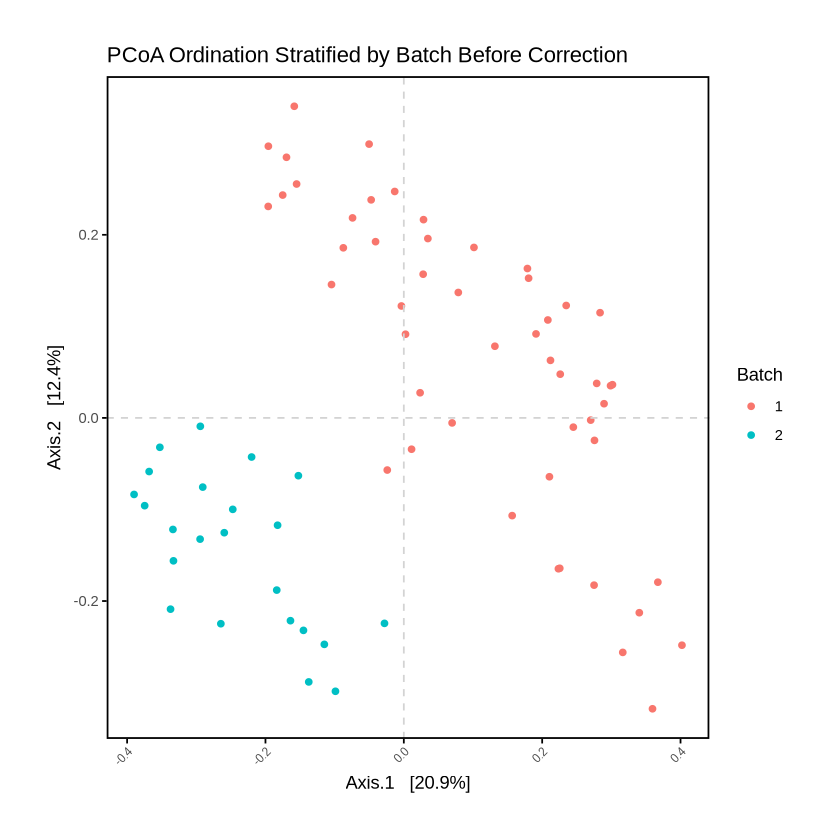

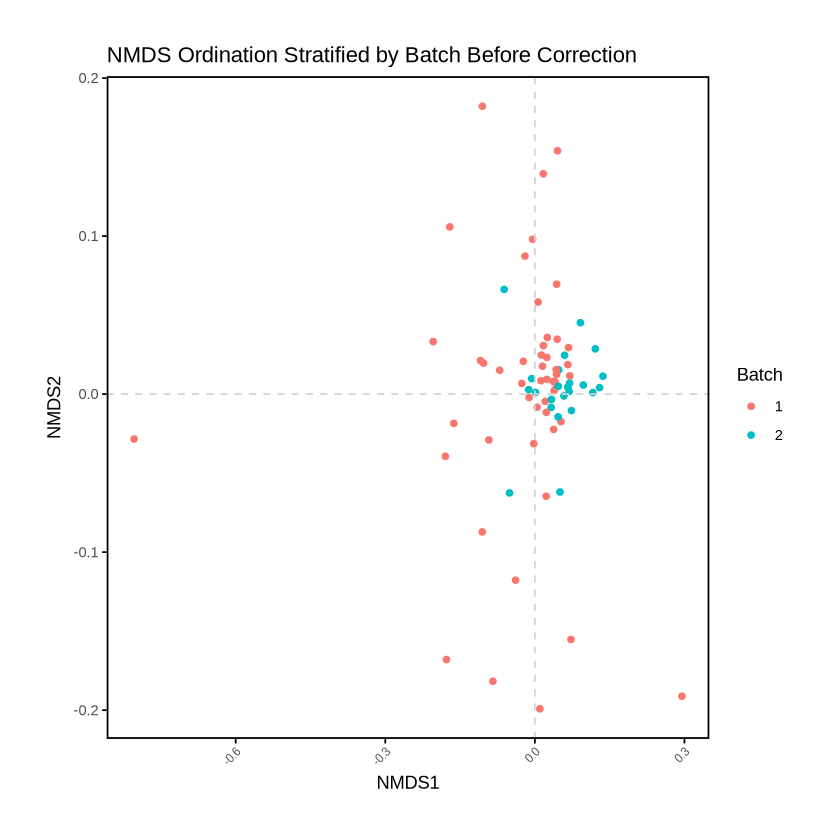

In [7]:
# Step 2: Visualize Richness and Heatmap Before Batch Correction
# Plot alpha diversity (richness) by group (e.g., case/control)
plot_richness(physeq_GH, color = "Group", measures = c("Chao1", "Shannon", "Simpson")) +
  ggtitle("Richness Stratified by Group") +
  geom_point(size = 0.5)+
  theme_minimal() +
  theme(
        panel.grid = element_blank(),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right",
        axis.text.x = element_blank(),
        axis.title.x = element_blank())+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))

# Plot heatmap of OTU abundance stratified by group before correction
plot_heatmap(physeq_filtered, sample.label = "Group", distance = "bray", sample.order = "Group") +
  ggtitle("Heatmap of OTU Abundance Stratified by Group Before Correction") +
  theme_minimal()

# Step 3: Ordination and PERMANOVA Before Batch Correction
# Perform ordination (PCoA) before batch correction
ordination_result_pcoa <- ordinate(physeq_filtered, method = "PCoA", distance = "bray")
plot_ordination(physeq, ordination_result_pcoa, color = "Batch") +
  ggtitle("PCoA Ordination Stratified by Batch Before Correction") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5)+
  # Add threshold line for baseMean
  geom_vline(xintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right")+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))

# Perform ordination (NMDS) before batch correction
ordination_result_nmds <- ordinate(physeq_filtered, method = "NMDS", distance = "bray")
plot_ordination(physeq, ordination_result_nmds, color = "Batch") +
  ggtitle("NMDS Ordination Stratified by Batch Before Correction") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5)+
  # Add threshold line for baseMean
  geom_vline(xintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right")+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))


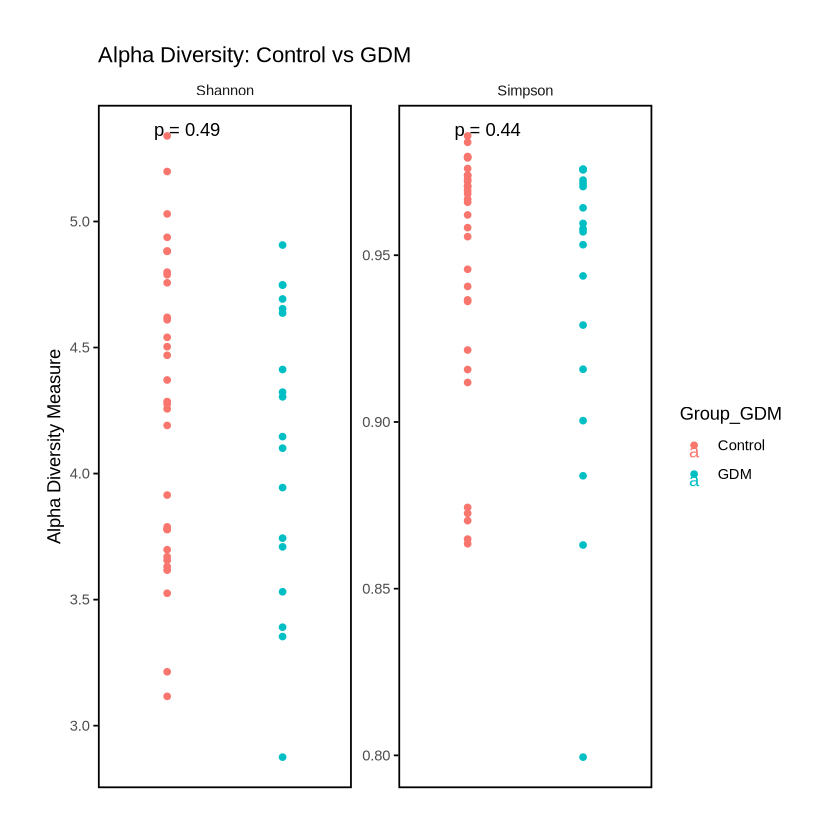

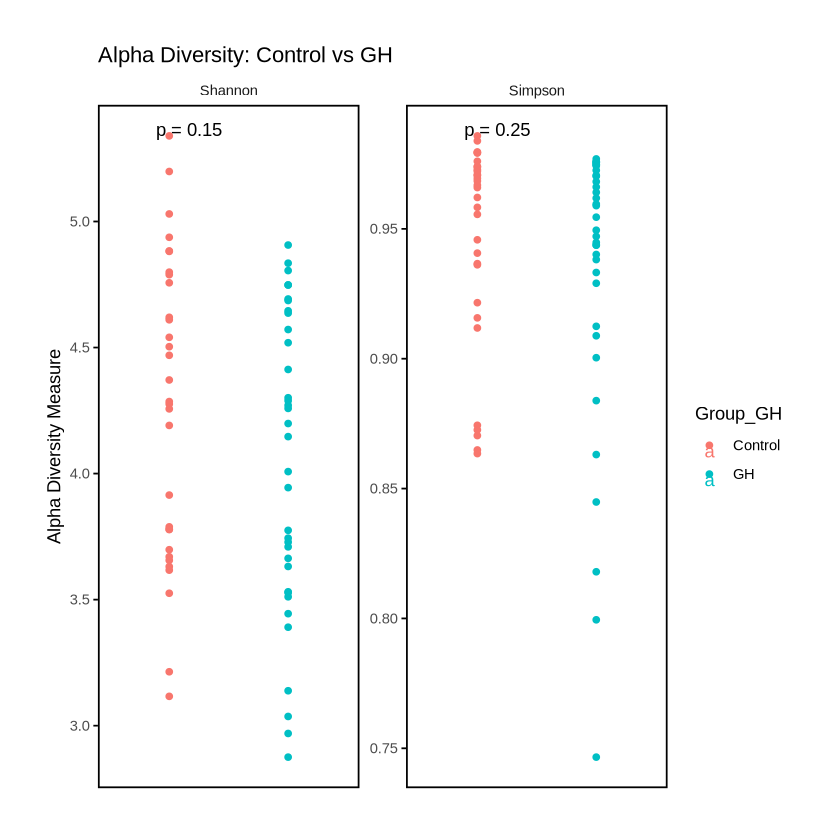

In [8]:
library(ggpubr)

plot_richness(
  physeq_GDM,
  x = "Group_GDM",
  color = "Group_GDM",
  measures = c("Shannon", "Simpson")
) +
  ggtitle("Alpha Diversity: Control vs GDM") +
  geom_point(size = 0.5) +
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format"
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "right",
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    plot.margin = margin(1, 1, 1, 1, "cm")
  )


plot_richness(
  physeq_GH,
  x = "Group_GH",
  color = "Group_GH",
  measures = c("Shannon", "Simpson")
) +
  ggtitle("Alpha Diversity: Control vs GH") +
  geom_point(size = 0.5) +
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format"
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "right",
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    plot.margin = margin(1, 1, 1, 1, "cm")
  )



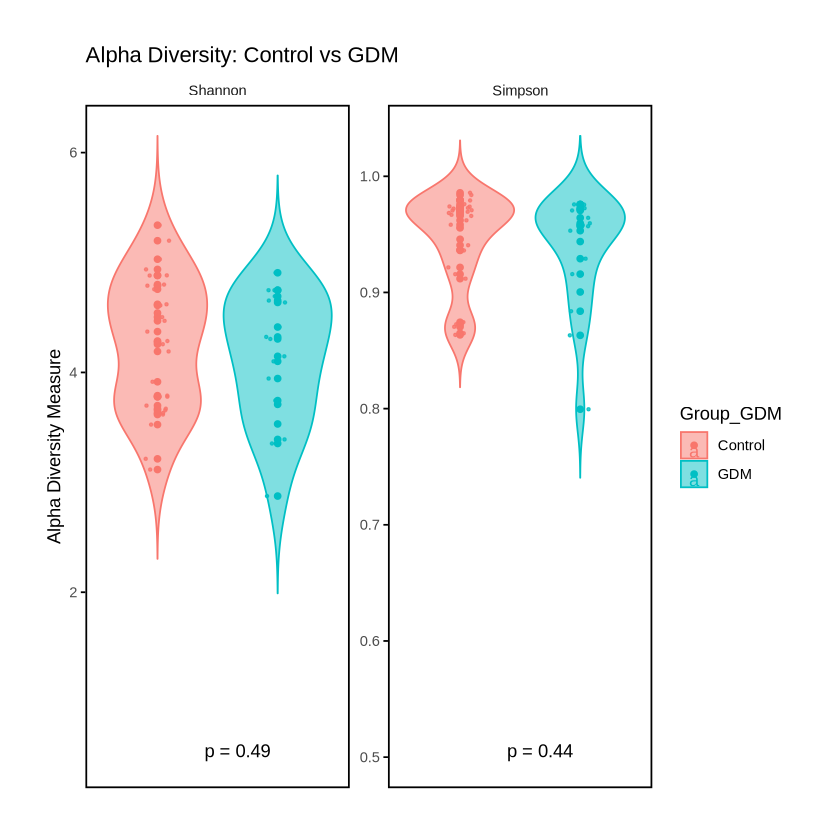

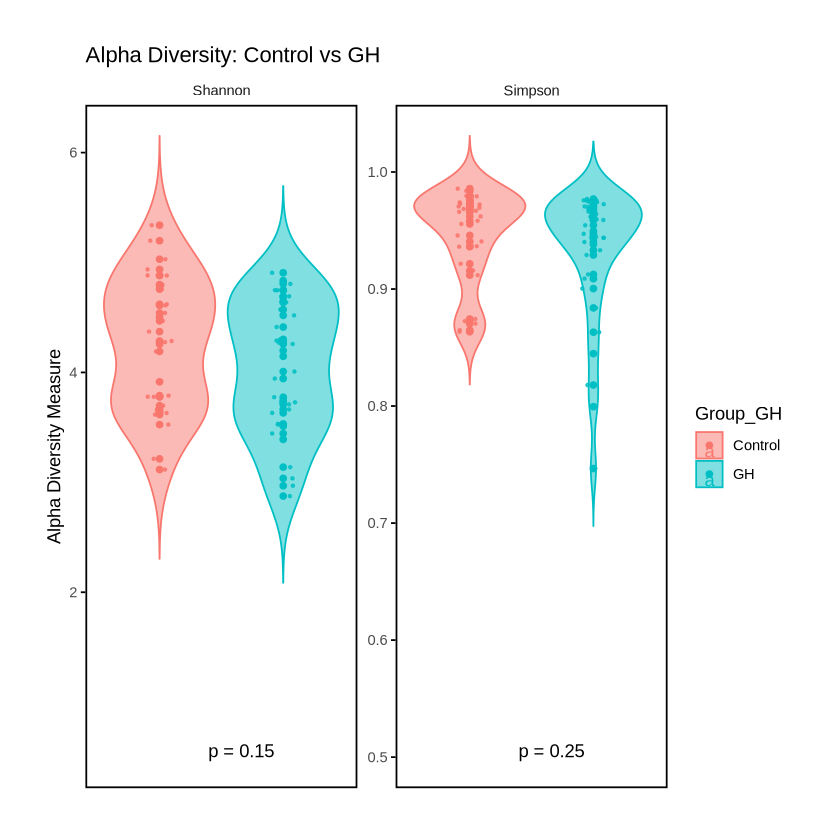

In [9]:
library(ggpubr)

plot_richness(
  physeq_GDM,
  x = "Group_GDM",
  color = "Group_GDM",
  measures = c("Shannon", "Simpson")
) +
  ggtitle("Alpha Diversity: Control vs GDM") +
  geom_violin(
    aes(fill = Group_GDM),
    trim = FALSE,
    alpha = 0.5
  ) +
  geom_jitter(
    width = 0.1,
    size = 0.6,
    alpha = 0.8
  ) +
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format",
    label.x = 1.5,   # centers between Control (1) and GDM (2)
    label.y = 0.5
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "right",
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    plot.margin = margin(1, 1, 1, 1, "cm")
  )

plot_richness(
  physeq_GH,
  x = "Group_GH",
  color = "Group_GH",
  measures = c("Shannon", "Simpson")
) +
  ggtitle("Alpha Diversity: Control vs GH") +
  geom_violin(
    aes(fill = Group_GH),
    trim = FALSE,
    alpha = 0.5
  ) +
  geom_jitter(
    width = 0.1,
    size = 0.6,
    alpha = 0.8
  ) +
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format",
    label.x = 1.5,   # centers between Control (1) and GH (2)
    label.y = 0.5
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "right",
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    plot.margin = margin(1, 1, 1, 1, "cm")
  )


In [10]:
# Test for batch effects using PERMANOVA before correction
dist_matrix_before <- phyloseq::distance(physeq_filtered, method = "bray")
sample_data_df_before <- as(sample_data(physeq_filtered), "data.frame")
adonis_before <- adonis2(dist_matrix_before ~ Batch, data = sample_data_df_before)
print(adonis_before)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix_before ~ Batch, data = sample_data_df_before)
         Df SumOfSqs      R2      F Pr(>F)    
Model     1   2.7698 0.15846 13.369  0.001 ***
Residual 71  14.7100 0.84154                  
Total    72  17.4798 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Correct batch affects with log transformation and rescaling to psuedo-counts

In [11]:
# Step 4: Correct Batch Effects Using Limma-Voom
# Extract the OTU count table from phyloseq
otu_counts <- as(otu_table(physeq_filtered), "matrix")
batch <- sample_data(physeq_filtered)$Batch
group <- sample_data(physeq_filtered)$Group  # Condition grouping (e.g., case/control)

# Create DGEList object and normalize counts
y <- DGEList(counts = otu_counts)
y <- calcNormFactors(y)

# Use voom to transform count data for linear modeling
design <- model.matrix(~ batch + group)
v <- voom(y, design, plot = FALSE)

# Fit the linear model and correct for batch effects
fit <- lmFit(v, design)
corrected_logCPM <- removeBatchEffect(v$E, batch = batch)

# Create a new phyloseq object with the corrected logCPM values
physeq_corrected_log <- physeq_filtered  # Copy the original phyloseq object
otu_table(physeq_corrected_log) <- otu_table(corrected_logCPM, taxa_are_rows = TRUE)

# Convert log-transformed values back to original scale
exp_corrected <- exp(corrected_logCPM)

# Create a new phyloseq object with the exponentiated values
otu_table(physeq_corrected_log) <- otu_table(exp_corrected, taxa_are_rows = TRUE)


In [12]:
## Inspect and prepare metadata
md <- as.data.frame(sample_data(physeq_corrected_log))

# Check labels
table(md$Hypertension, useNA = "ifany")
table(md$GDM, useNA = "ifany")

# Standardize as factors (optional but recommended)
md$Hypertension <- factor(md$Hypertension, levels = c("No", "Yes"))
md$GDM          <- factor(md$GDM, levels = c("No", "Yes"))

sample_data(physeq_corrected_log) <- sample_data(md)

## -------------------------
## Control vs GH
## -------------------------

physeq_GH <- subset_samples(
  physeq_corrected_log,
  Hypertension == "Yes" | (Hypertension == "No" & GDM == "No")
)

# Create grouping variable
md_GH <- as.data.frame(sample_data(physeq_GH))
md_GH$Group_GH <- ifelse(md_GH$Hypertension == "Yes", "GH", "Control")
md_GH$Group_GH <- factor(md_GH$Group_GH, levels = c("Control", "GH"))
sample_data(physeq_GH) <- sample_data(md_GH)

# Sanity check
table(md_GH$Group_GH)


## -------------------------
## Control vs GDM
## -------------------------

physeq_GDM <- subset_samples(
  physeq_corrected_log,
  GDM == "Yes" | (Hypertension == "No" & GDM == "No")
)

# Create grouping variable
md_GDM <- as.data.frame(sample_data(physeq_GDM))
md_GDM$Group_GDM <- ifelse(md_GDM$GDM == "Yes", "GDM", "Control")
md_GDM$Group_GDM <- factor(md_GDM$Group_GDM, levels = c("Control", "GDM"))
sample_data(physeq_GDM) <- sample_data(md_GDM)

# Sanity check
table(md_GDM$Group_GDM)



  No  Yes <NA> 
  37   35    1 


  No  Yes <NA> 
  54   18    1 


Control      GH 
     31      35 


Control     GDM 
     31      18 

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1341005 
Run 1 stress 0.1449682 
Run 2 stress 0.1497103 
Run 3 stress 0.1495135 
Run 4 stress 0.1525665 
Run 5 stress 0.1580054 
Run 6 stress 0.1560824 
Run 7 stress 0.1462818 
Run 8 stress 0.1467733 
Run 9 stress 0.1435493 
Run 10 stress 0.1443589 
Run 11 stress 0.1467938 
Run 12 stress 0.1592499 
Run 13 stress 0.1479601 
Run 14 stress 0.1588418 
Run 15 stress 0.1546788 
Run 16 stress 0.1577917 
Run 17 stress 0.156088 
Run 18 stress 0.1533412 
Run 19 stress 0.1467942 
Run 20 stress 0.1549214 
*** Best solution was not repeated -- monoMDS stopping criteria:
    20: stress ratio > sratmax


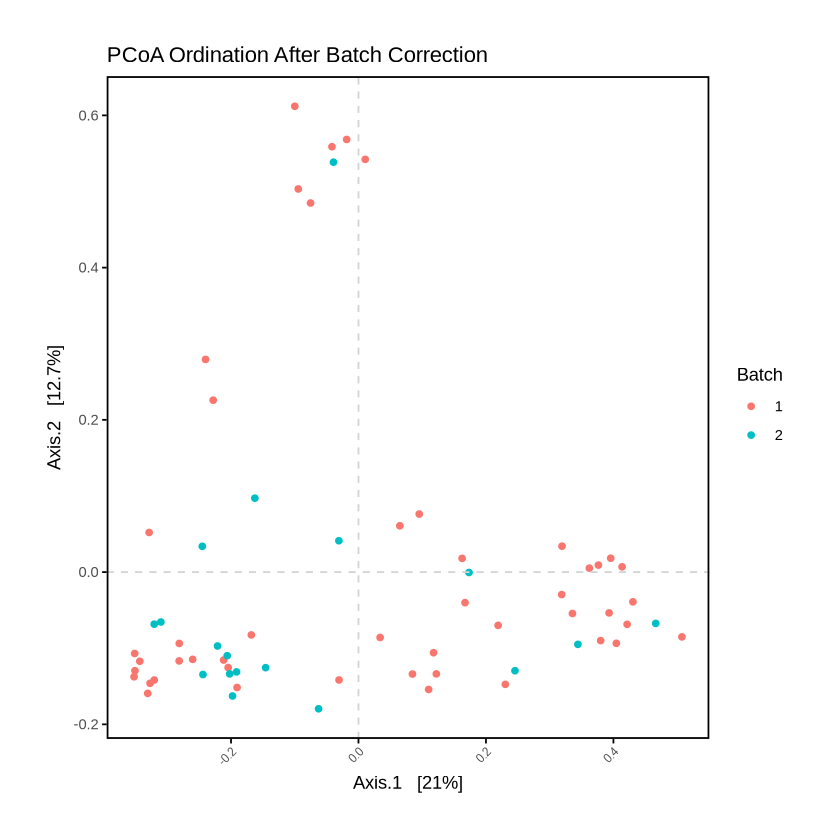

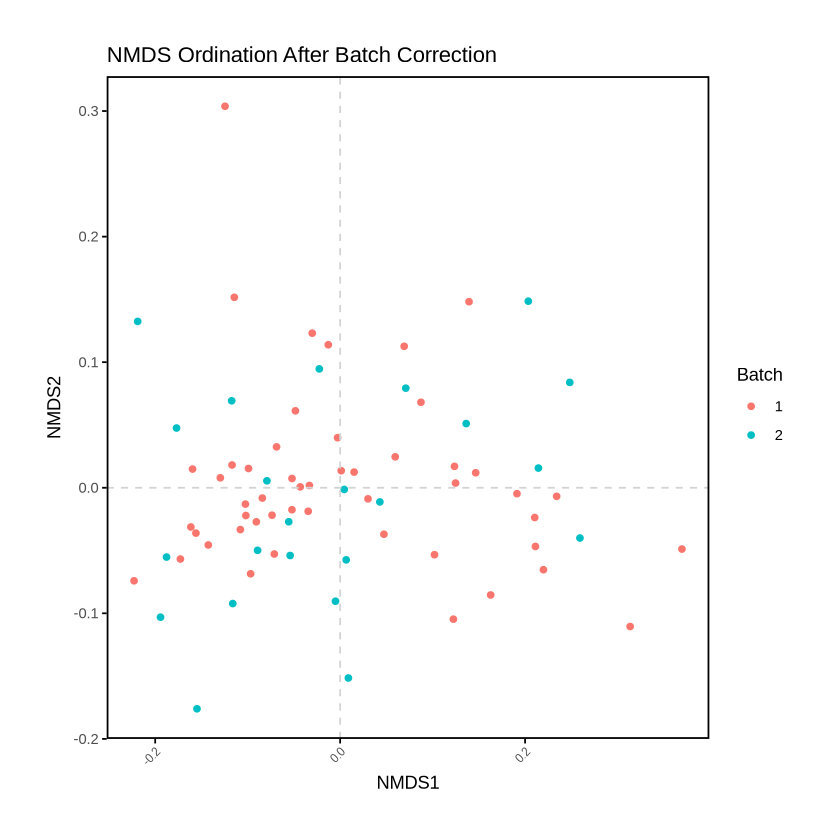

In [13]:

# Step 5: Ordination and PERMANOVA After Batch Correction

# Perform ordination (PCoA) after batch correction
ordination_result_corrected_pcoa <- ordinate(physeq_GH, method = "PCoA", distance = "bray")
plot_ordination(physeq_corrected_log, ordination_result_corrected_pcoa, color = "Batch") +
  ggtitle("PCoA Ordination After Batch Correction") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5)+
  # Add threshold line for baseMean
  geom_vline(xintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right")+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))

# Perform ordination (NMDS) after batch correction
ordination_result_corrected_nmds <- ordinate(physeq_corrected_log, method = "NMDS", distance = "bray")
plot_ordination(physeq_corrected_log, ordination_result_corrected_nmds, color = "Batch") +
  ggtitle("NMDS Ordination After Batch Correction") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5)+
  # Add threshold line for baseMean
  geom_vline(xintercept = 0, linetype = "dashed", color = "lightgray", size = 0.5) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right")+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))


In [14]:


# Test for batch effects using PERMANOVA after correction
dist_matrix_after <- phyloseq::distance(physeq_corrected_log, method = "bray")
sample_data_df_after <- as(sample_data(physeq_corrected_log), "data.frame")
adonis_after <- adonis2(dist_matrix_after ~ Batch, data = sample_data_df_after)
print(adonis_after)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix_after ~ Batch, data = sample_data_df_after)
         Df SumOfSqs      R2      F Pr(>F)
Model     1   0.3829 0.01587 1.1452  0.284
Residual 71  23.7377 0.98413              
Total    72  24.1206 1.00000              


In [15]:
library(vegan)

dist_GDM <- phyloseq::distance(physeq_GDM, method = "bray")

meta_GDM <- as(sample_data(physeq_GDM), "data.frame")

adonis_GDM <- adonis2(
  dist_GDM ~ Group_GDM,
  data = meta_GDM,
  permutations = 999
)

pval_GDM <- adonis_GDM$`Pr(>F)`[1]


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCoA (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCoA (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCoA (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCoA (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCoA (Bray–Curtis): Control vs GDM (after batch 

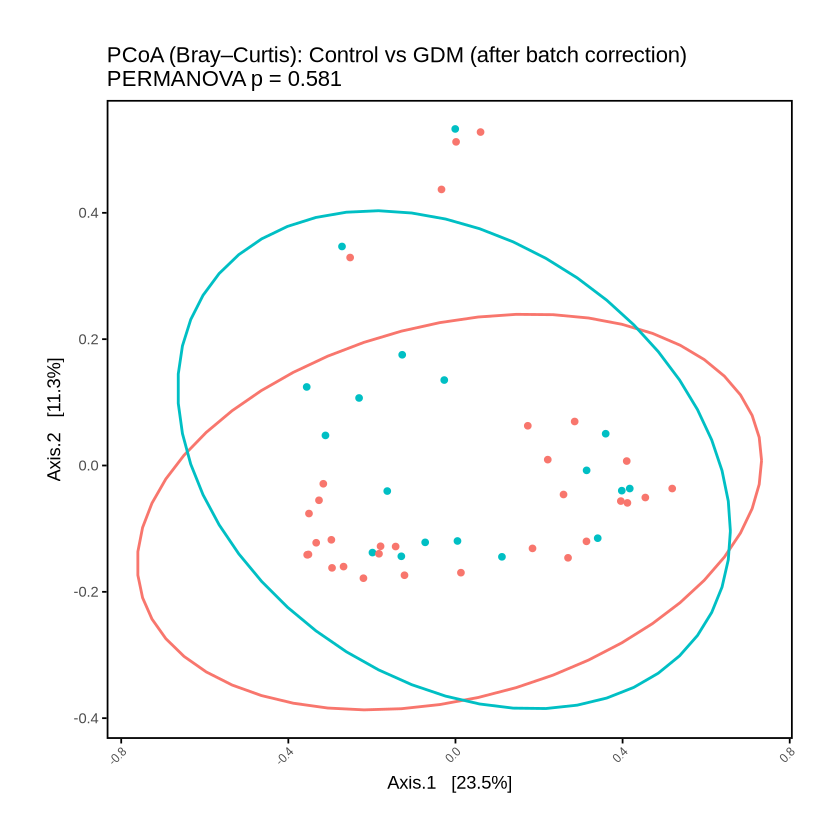

In [16]:
ordination_result_corrected_pcoa <- ordinate(
  physeq_GDM,
  method = "PCoA",
  distance = dist_GDM
)

plot_ordination(
  physeq_GDM,
  ordination_result_corrected_pcoa,
  color = "Group_GDM"
) +
  stat_ellipse(
    aes(group = Group_GDM),
    type = "t",
    level = 0.95,
    linewidth = 0.8
  ) +
  ggtitle(
    paste0(
      "PCoA (Bray–Curtis): Control vs GDM (after batch correction)\n",
      "PERMANOVA p = ", signif(pval_GDM, 3)
    )
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
    panel.grid = element_blank(),
    axis.ticks.x = element_line(color = "black", linewidth = 0.5),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "riGDMt",
    plot.margin = margin(1, 1, 1, 1, "cm")
  )


Square root transformation
Wisconsin double standardization
Run 0 stress 0.1302999 
Run 1 stress 0.1459196 
Run 2 stress 0.1483411 
Run 3 stress 0.1480822 
Run 4 stress 0.1485212 
Run 5 stress 0.1370456 
Run 6 stress 0.1444944 
Run 7 stress 0.1506383 
Run 8 stress 0.1514385 
Run 9 stress 0.1420815 
Run 10 stress 0.1514977 
Run 11 stress 0.1468442 
Run 12 stress 0.1508994 
Run 13 stress 0.1517564 
Run 14 stress 0.1483937 
Run 15 stress 0.1514681 
Run 16 stress 0.1459471 
Run 17 stress 0.1527097 
Run 18 stress 0.1540714 
Run 19 stress 0.1544012 
Run 20 stress 0.1497885 
Run 21 stress 0.1314069 
Run 22 stress 0.1524122 
Run 23 stress 0.1483734 
Run 24 stress 0.1508775 
Run 25 stress 0.1420087 
Run 26 stress 0.1488623 
Run 27 stress 0.1486297 
Run 28 stress 0.1434476 
Run 29 stress 0.1476048 
Run 30 stress 0.1517003 
Run 31 stress 0.1517 
Run 32 stress 0.154658 
Run 33 stress 0.1540014 
Run 34 stress 0.1505374 
Run 35 stress 0.1412957 
Run 36 stress 0.1369289 
Run 37 stress 0.1513548 
Run 

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NMDS (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NMDS (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NMDS (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NMDS (Bray–Curtis): Control vs GDM (after batch correction)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NMDS (Bray–Curtis): Control vs GDM (after batch 

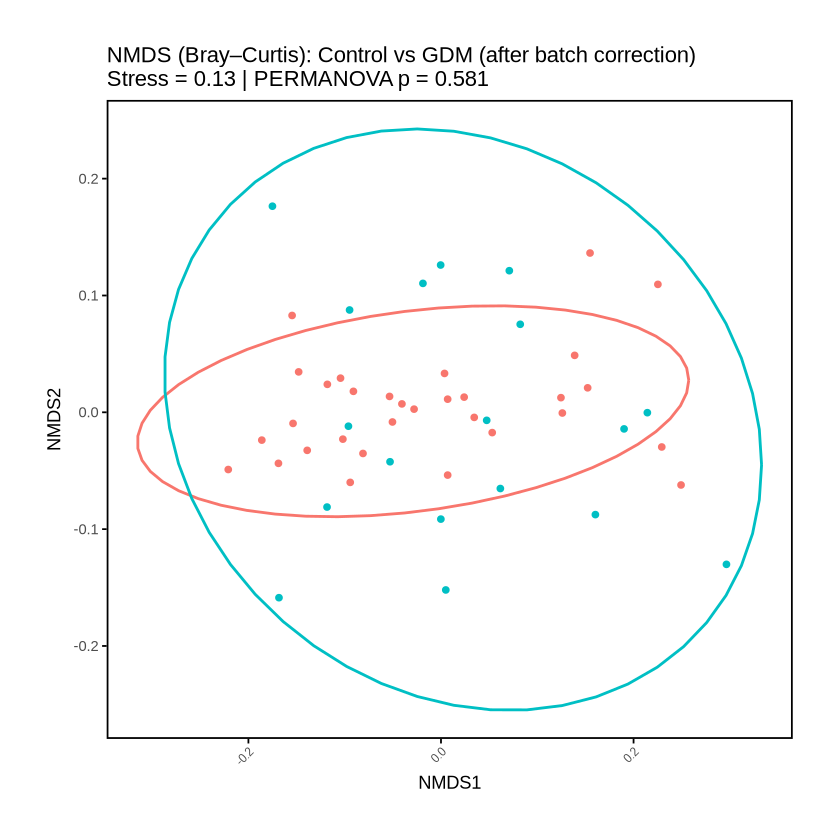

In [17]:
ordination_result_corrected_nmds <- ordinate(
  physeq_GDM,
  method = "NMDS",
  distance = "bray",
  trymax = 100
)

stress_GDM <- ordination_result_corrected_nmds$stress

plot_ordination(
  physeq_GDM,
  ordination_result_corrected_nmds,
  color = "Group_GDM"
) +
  stat_ellipse(
    aes(group = Group_GDM),
    type = "t",
    level = 0.95,
    linewidth = 0.8
  ) +
  ggtitle(
    paste0(
      "NMDS (Bray–Curtis): Control vs GDM (after batch correction)\n",
      "Stress = ", signif(stress_GDM, 3),
      " | PERMANOVA p = ", signif(pval_GDM, 3)
    )
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
    panel.grid = element_blank(),
    axis.ticks.x = element_line(color = "black", linewidth = 0.5),
    axis.ticks.y = element_line(color = "black", linewidth = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "riGDMt",
    plot.margin = margin(1, 1, 1, 1, "cm")
  )


## Differential Abundance Analysis

In [22]:

# Convert phyloseq object to DESeq2 object for differential analysis
# Extract sample metadata for design
design <- ~ Batch + Group  # Replace with your specific design formula

ddsgh <- phyloseq_to_deseq2(physeq_GH, design)

# Perform differential abundance analysis
ddsgh <- DESeq(ddsgh)

# Extract results for plotting
resgh <- results(ddsgh, contrast = c("Group", "Case", "Control"))

summary(resgh)


# Convert phyloseq object to DESeq2 object for differential analysis
# Extract sample metadata for design
design <- ~ Batch + Group  # Replace with your specific design formula

ddsgdm <- phyloseq_to_deseq2(physeq_GDM, design)

# Perform differential abundance analysis
ddsgdm <- DESeq(ddsgdm)

# Extract results for plotting
resgdm <- results(ddsgdm, contrast = c("Group", "Case", "Control"))

summary(resgdm)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1259 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




out of 12991 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 267, 2.1%
LFC < 0 (down)     : 147, 1.1%
outliers [1]       : 343, 2.6%
low counts [2]     : 3913, 30%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1310 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




out of 12837 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 63, 0.49%
LFC < 0 (down)     : 35, 0.27%
outliers [1]       : 0, 0%
low counts [2]     : 3748, 29%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Removed 280 rows containing missing values or values outside the scale range
(`geom_point()`).”


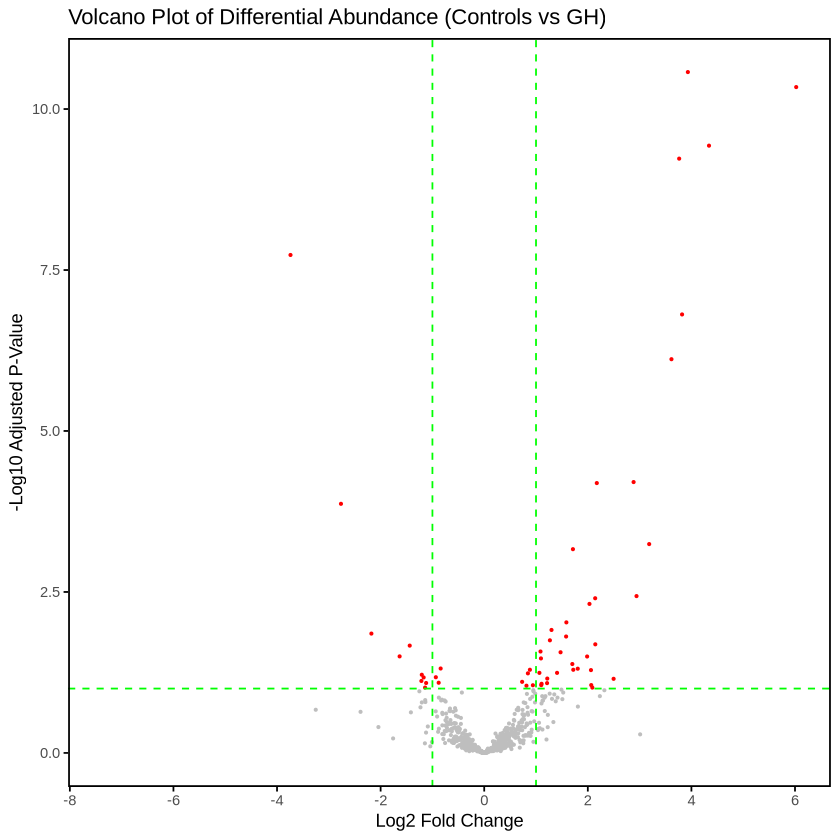

In [23]:
# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Convert results to data frame
res_df_gh <- as.data.frame(resgh)

# Ensure that the row names of res_df match the OTU IDs and add taxonomic labels
res_df_gh$OTU <- rownames(res_df_gh)

# Merge the taxonomic data with DESeq2 results to add taxonomic names
res_tax_df_gh <- merge(res_df_gh, tax_table_df, by.x = "OTU", by.y = "row.names", all.x = TRUE)

# Step 3: Remove Rows with All NA Values in Taxonomic Columns
# Remove rows where all taxonomic levels are NA or empty
res_tax_df_gh <- res_tax_df_gh[!apply(res_tax_df_gh[, c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")], 1, function(row) {
  any(is.na(row) | row == "")
}), ]


# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Convert results to data frame
res_df_gdm <- as.data.frame(resgdm)

# Ensure that the row names of res_df match the OTU IDs and add taxonomic labels
res_df_gdm$OTU <- rownames(res_df_gdm)

# Merge the taxonomic data with DESeq2 results to add taxonomic names
res_tax_df_gdm <- merge(res_df_gdm, tax_table_df, by.x = "OTU", by.y = "row.names", all.x = TRUE)

# Step 3: Remove Rows with All NA Values in Taxonomic Columns
# Remove rows where all taxonomic levels are NA or empty
res_tax_df_gdm <- res_tax_df_gdm[!apply(res_tax_df_gdm[, c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")], 1, function(row) {
  any(is.na(row) | row == "")
}), ]


# Create the volcano plot using ggplot2

ggplot(res_tax_df_gh, aes(x = log2FoldChange, y = -log10(padj))) +
  # Use smaller point sizes and set alpha transparency
  geom_point(aes(color = padj < 0.1), size = 0.5) +
  # Manually define colors for significant vs non-significant points
  scale_color_manual(values = c("gray", "red")) +
  # Add informative threshold lines
  geom_hline(yintercept = -log10(0.1), linetype = "dashed", color = "green", size = 0.5) +  # Horizontal line for p-value threshold
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "green", size = 0.5) +  # Vertical lines for log2 fold change threshold
  scale_x_continuous(breaks = seq(-10, 40, by = 2))+
  # Customize theme to remove gridlines
  theme_minimal() +
  theme(panel.grid = element_blank(),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        legend.position = "none",
        axis.ticks = element_line(color = "black")) +
  # Add labels to the plot
  labs(title = "Volcano Plot of Differential Abundance (Controls vs GH)",
       x = "Log2 Fold Change",
       y = "-Log10 Adjusted P-Value")


Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 70 rows containing missing values or values outside the scale range
(`geom_point()`).”


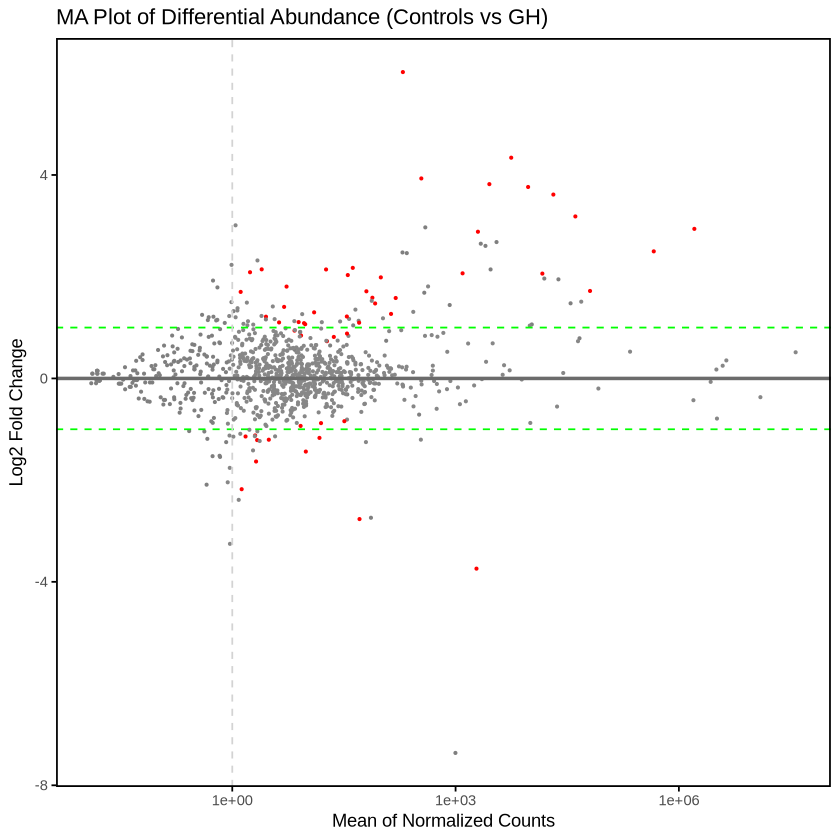

In [24]:


# Create the MA plot using ggplot2
ggplot(res_tax_df_gh, aes(x = baseMean, y = log2FoldChange)) +
  # Plot points with significance highlighted
  geom_point(aes(color = padj < 0.1),size = 0.5) +
  # Custom colors for significant vs non-significant points
  scale_color_manual(values = c("gray53", "red"), labels = c("Not Significant", "Significant")) +
  # Add threshold lines for log2 fold change
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", color = "green", size = 0.5) +
  geom_hline(yintercept = 0, color = "gray42", size = 1)+
  # Add threshold line for baseMean
  geom_vline(xintercept = 1, linetype = "dashed", color = "lightgray", size = 0.5) +
  # Set scale for x-axis to be log10 to show the mean counts more clearly
  scale_x_continuous(trans = 'log10') +
  # Customize the theme to match your desired style
  theme_minimal() +
  theme(panel.grid = element_blank(),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "none",  # Remove legend
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5)) +
  # Add axis labels and title
  labs(title = "MA Plot of Differential Abundance (Controls vs GH)",
       x = "Mean of Normalized Counts",
       y = "Log2 Fold Change")

Filter most significantly differentially abundant taxa (adjusted p-value < 0.1)

In [27]:

# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Step 2: Merge Taxonomic Table with DESeq2 Results
# Convert DESeq2 results to a data frame
res_df_gh <- as.data.frame(resgh)

# Ensure that the row names of res_df match the OTU IDs and add taxonomic labels
res_df_gh$OTU <- rownames(res_df_gh)

# Merge the taxonomic data with DESeq2 results to add taxonomic names
res_tax_df_gh <- merge(res_df_gh, tax_table_df, by.x = "OTU", by.y = "row.names", all.x = TRUE)

# Step 3: Remove Rows with All NA Values in Taxonomic Columns
# Remove rows where all taxonomic levels are NA or empty
res_tax_df_gh <- res_tax_df_gh[!apply(res_tax_df_gh[, c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")], 1, function(row) {
  any(is.na(row) | row == "")
}), ]

# Create a descriptive label with "Genus Species" if both are available, otherwise use available genus or fallback
res_tax_df_gh$taxa_label <- apply(res_tax_df_gh[, c("Genus", "Species")], 1, function(row) {
  genus <- row["Genus"]
  species <- row["Species"]
  
  if (!is.na(genus) & genus != "" & !is.na(species) & species != "") {
    return(paste(genus, species, sep = " "))  # Concatenate Genus and Species
  } else if (!is.na(genus) & genus != "") {
    return(genus)  # Use Genus if Species is missing
  } else if (!is.na(species) & species != "") {
    return(species)  # Rare case where only Species is available
  } else {
    return(row["row.names"])  # Fallback to OTU ID if both are missing
  }
})


# Sort by adjusted p-value and select the top 5 significant taxa
top_res_gh <- res_tax_df_gh[order(res_tax_df_gh$padj), ][1:10, ]

# Ensure order by log2 fold change for waterfall plotting
top_res_gh <- top_res_gh[order(top_res_gh$log2FoldChange), ]

print(top_res_gh)

       OTU    baseMean log2FoldChange     lfcSE      stat       pvalue
16363  905  1908.99651      -3.740076 0.5595294 -6.684324 2.319925e-11
16233  861    51.22402      -2.765618 0.5518659 -5.011395 5.403675e-07
2129  1613    41.58938       2.173458 0.4199934  5.174982 2.279327e-07
1168  1350  1996.76627       2.883827 0.5558870  5.187793 2.128010e-07
15102  570 20588.06480       3.614776 0.5979343  6.045440 1.490031e-09
2349  1660  9429.64262       3.763694 0.5238372  7.184855 6.727854e-13
2448  1689  2844.18932       3.819672 0.6035689  6.328477 2.475935e-10
892   1280   346.61124       3.931682 0.5115609  7.685658 1.522125e-14
2168  1623  5590.53396       4.339688 0.5962626  7.278150 3.384294e-13
14940  545   195.89014       6.023050 0.7932308  7.593062 3.124338e-14
              padj  Kingdom       Phylum            Class
16363 1.847082e-08 Bacteria Bacteroidota    Chitinophagia
16233 1.352154e-04 Bacteria Bacteroidota Sphingobacteriia
2129  6.439466e-05 Bacteria    Bacillota     

In [28]:

# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Step 2: Merge Taxonomic Table with DESeq2 Results
# Convert DESeq2 results to a data frame
res_df_gdm <- as.data.frame(resgdm)

# Ensure that the row names of res_df match the OTU IDs and add taxonomic labels
res_df_gdm$OTU <- rownames(res_df_gdm)

# Merge the taxonomic data with DESeq2 results to add taxonomic names
res_tax_df_gdm <- merge(res_df_gdm, tax_table_df, by.x = "OTU", by.y = "row.names", all.x = TRUE)

# Step 3: Remove Rows with All NA Values in Taxonomic Columns
# Remove rows where all taxonomic levels are NA or empty
res_tax_df_gdm <- res_tax_df_gdm[!apply(res_tax_df_gdm[, c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")], 1, function(row) {
  any(is.na(row) | row == "")
}), ]

# Create a descriptive label with "Genus Species" if both are available, otherwise use available genus or fallback
res_tax_df_gdm$taxa_label <- apply(res_tax_df_gdm[, c("Genus", "Species")], 1, function(row) {
  genus <- row["Genus"]
  species <- row["Species"]
  
  if (!is.na(genus) & genus != "" & !is.na(species) & species != "") {
    return(paste(genus, species, sep = " "))  # Concatenate Genus and Species
  } else if (!is.na(genus) & genus != "") {
    return(genus)  # Use Genus if Species is missing
  } else if (!is.na(species) & species != "") {
    return(species)  # Rare case where only Species is available
  } else {
    return(row["row.names"])  # Fallback to OTU ID if both are missing
  }
})


# Sort by adjusted p-value and select the top 5 significant taxa
top_res_gdm <- res_tax_df_gdm[order(res_tax_df_gdm$padj), ][1:10, ]

# Ensure order by log2 fold change for waterfall plotting
top_res_gdm <- top_res_gdm[order(top_res_gdm$log2FoldChange), ]

print(top_res_gdm)

       OTU    baseMean log2FoldChange     lfcSE      stat       pvalue
16188  850 1374.203928      -6.900222 0.9105065 -7.578443 3.497261e-14
16363  905 2348.914913      -2.728568 0.6612619 -4.126305 3.686386e-05
16233  861   66.201869      -2.575040 0.6463639 -3.983885 6.779760e-05
16214  856   95.648368      -2.276479 0.6590799 -3.454026 5.522850e-04
14686  490    2.067935      -2.030653 0.5818198 -3.490174 4.827055e-04
1074  1329   27.804801      -1.997337 0.5065309 -3.943170 8.041161e-05
3257  1877   10.929339       1.524498 0.3775734  4.037619 5.399638e-05
4451  2047   22.295659       1.836918 0.4807810  3.820695 1.330760e-04
2168  1623 1926.817177       2.862202 0.5346523  5.353389 8.632217e-08
892   1280  333.007639       3.323343 0.6092651  5.454675 4.906255e-08
              padj  Kingdom       Phylum            Class                Order
16188 1.601920e-10 Bacteria Bacteroidota Sphingobacteriia   Sphingobacteriales
16363 1.055343e-02 Bacteria Bacteroidota    Chitinophagia    

In [30]:
install.packages("VennDiagram", repos = "https://cloud.r-project.org")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



[1] 8

[1] 30

[1] "Dehalobacterium formicoaceticum" "Lysinibacillus agricola"        
[3] "Paenibacillus sp. FSL E2-0178"   "Sphingobacterium faecium"       
[5] "Chitinophaga niabensis"

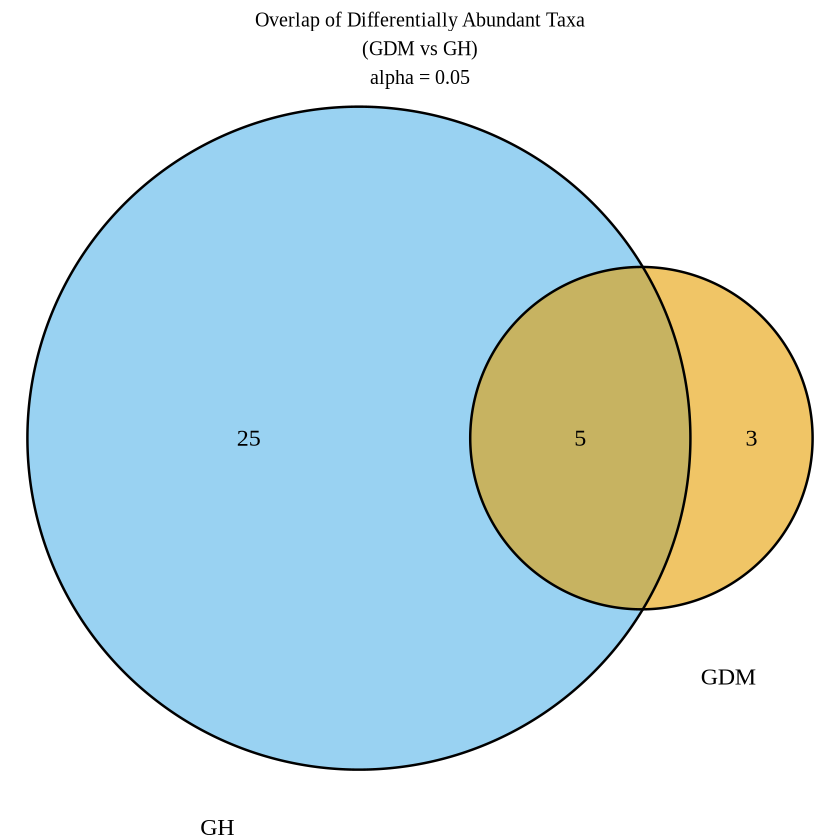

In [35]:
## ---------------------------------------------
## Overlap analysis (Venn diagram): GDM vs GH
## Differentially abundant taxa (DESeq2-based)
## ---------------------------------------------

library(VennDiagram)
library(grid)
library(dplyr)

## ---- Assumptions ----
## You already have:
##   res_tax_df_gdm : DESeq2 + taxonomy table for GDM
##   res_tax_df_gh  : DESeq2 + taxonomy table for GH
## Both contain columns: padj, taxa_label

## ---- Significance threshold ----
alpha <- 0.05

## ---- Extract significant taxa sets ----
sig_gdm <- res_tax_df_gdm %>%
  filter(!is.na(padj), padj < alpha) %>%
  pull(taxa_label) %>%
  unique()

sig_gh <- res_tax_df_gh %>%
  filter(!is.na(padj), padj < alpha) %>%
  pull(taxa_label) %>%
  unique()

## Sanity checks
length(sig_gdm)
length(sig_gh)

## ---- Set operations (optional but useful) ----
shared_taxa <- intersect(sig_gdm, sig_gh)
gdm_only    <- setdiff(sig_gdm, sig_gh)
gh_only     <- setdiff(sig_gh, sig_gdm)

## Inspect shared taxa if desired
shared_taxa

## ---- Venn diagram ----
venn.plot <- venn.diagram(
  x = list(
    GDM = sig_gdm,
    GH  = sig_gh
  ),
  filename = NULL,
  fill = c("#E69F00", "#56B4E9"),
  alpha = 0.6,
  cex = 1.2,
  cat.cex = 1.2,
  cat.pos = c(-20, 20),
  cat.dist = 0.05,
  main = "Overlap of Differentially Abundant Taxa\n(GDM vs GH)\nalpha = 0.05",
)

grid.newpage()
grid.draw(venn.plot)


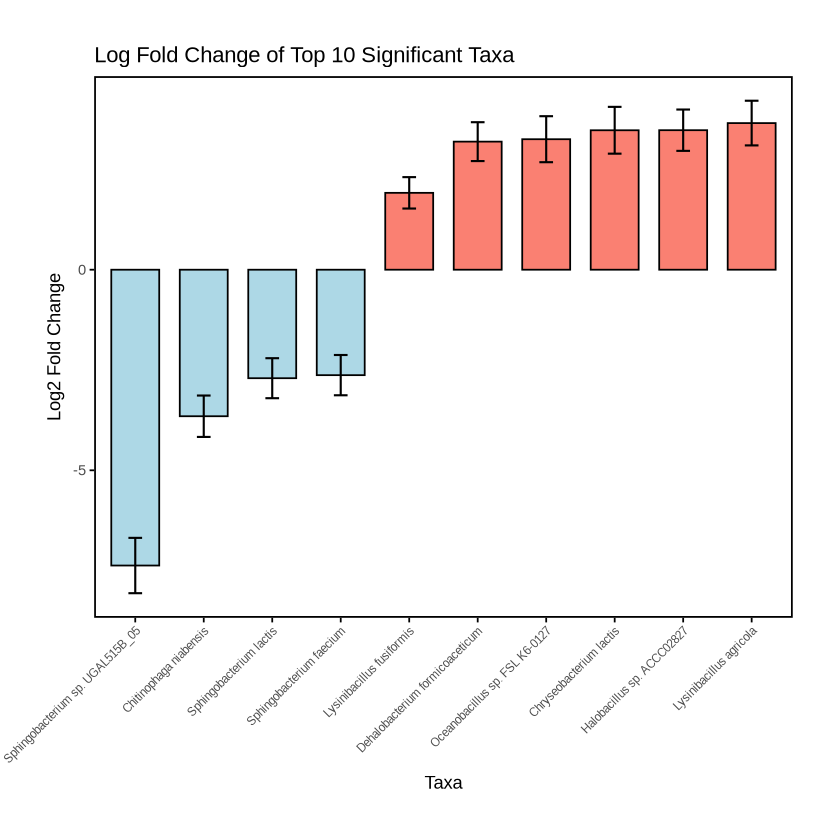

In [ ]:
# Load ggplot2 for plotting
library(ggplot2)

# Create the waterfall plot for the top significant taxa
ggplot(top_res, aes(x = reorder(taxa_label, log2FoldChange), y = log2FoldChange, fill = log2FoldChange > 0)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  geom_errorbar(aes(ymin = log2FoldChange - lfcSE, ymax = log2FoldChange + lfcSE), 
                width = 0.2, color = "black", size = 0.6) +
  # Customize the fill color for positive and negative log2 fold changes
  scale_fill_manual(values = c("lightblue", "salmon"), labels = c("Decreased", "Increased")) +
  # Add plot labels and theme customization
  labs(title = "Log Fold Change of Top 10 Significant Taxa",
       x = "Taxa",
       y = "Log2 Fold Change",
       fill = "Direction of Change") +
  theme_minimal() +
    theme(panel.grid = element_blank(),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "none",  # Remove legend
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1, size = 7))+
    theme(plot.margin = margin(1, 1, 1, 1, "cm"))

In [ ]:
# Load required packages
library(phyloseq)
library(reshape2)
library(dplyr)

# Step 1: Clean the Taxonomic Table
# Convert the taxonomic table to a data frame and rename columns to their taxonomic ranks
tax_table_df <- as.data.frame(tax_table(physeq_corrected_log))
colnames(tax_table_df) <- c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")

# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Ensure OTU IDs are set as row names in the tax table data frame
tax_table_df$OTU <- rownames(tax_table_df)

# Step 2: Extract the OTU Table from Phyloseq and Transform to Data Frame
# Extract the OTU count table from phyloseq
otu_counts <- as(otu_table(physeq_corrected_log), "matrix")

# Apply log10 transformation with pseudocount (to avoid issues with zeros)
otu_counts_log <- log10(otu_counts + 1)

# Convert OTU counts to a data frame
otu_counts_log_df <- as.data.frame(otu_counts_log)
otu_counts_log_df$OTU <- rownames(otu_counts_log_df)

# Convert counts to long format (melt) to facilitate merging
otu_counts_long <- melt(otu_counts_log_df, id.vars = "OTU", variable.name = "Sample", value.name = "relative_abundance")

# Step 3: Extract Sample Metadata from Phyloseq
# Convert sample data to a data frame and set Sample IDs
sample_data_df <- as(sample_data(physeq_corrected_log), "data.frame")
sample_data_df$Sample <- rownames(sample_data_df)

# Keep only the Group/Condition and Sample IDs for later merging
sample_group_df <- sample_data_df[, c("Sample", "Group")]

# Step 4: Merge OTU Abundance with Sample Metadata
# Merge OTU abundance data (in long format) with sample metadata (Group info)
otu_counts_long_with_group <- merge(otu_counts_long, sample_group_df, by = "Sample", all.x = TRUE)

# Step 5: Merge with Taxonomic Table
# Merge the long-format OTU data with the taxonomic information
merged_df <- merge(otu_counts_long_with_group, tax_table_df, by = "OTU", all.x = TRUE)

# Step 6: Create Descriptive Taxa Labels
# Create a new column that combines Genus and Species for labeling
merged_df$taxa_label <- apply(merged_df[, c("Genus", "Species")], 1, function(row) {
  genus <- row["Genus"]
  species <- row["Species"]

  if (!is.na(genus) & genus != "" & !is.na(species) & species != "") {
    return(paste(genus, species, sep = " "))  # Concatenate Genus and Species
  } else if (!is.na(genus) & genus != "") {
    return(genus)  # Use Genus if Species is missing
  } else if (!is.na(species) & species != "") {
    return(species)  # Rare case where only Species is available
  } else {
    return(row["OTU"])  # Fallback to OTU ID if both are missing
  }
})

# Step 7: Integrate DESeq2 Results for Top Significant Taxa
# Convert DESeq2 results to a data frame and add OTU IDs
res_df <- as.data.frame(res)
res_df$OTU <- rownames(res_df)

# Merge DESeq2 results with taxonomic information
res_tax_df <- merge(res_df, tax_table_df, by.x = "OTU", by.y = "OTU", all.x = TRUE)

# Remove rows with all NA values in taxonomic columns
res_tax_df <- res_tax_df[!apply(res_tax_df[, c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")], 1, function(row) {
  any(is.na(row) | row == "")
}), ]

# Create descriptive labels for taxa in res_tax_df
res_tax_df$taxa_label <- apply(res_tax_df[, c("Genus", "Species")], 1, function(row) {
  genus <- row["Genus"]
  species <- row["Species"]

  if (!is.na(genus) & genus != "" & !is.na(species) & species != "") {
    return(paste(genus, species, sep = " "))  # Concatenate Genus and Species
  } else if (!is.na(genus) & genus != "") {
    return(genus)  # Use Genus if Species is missing
  } else if (!is.na(species) & species != "") {
    return(species)  # Rare case where only Species is available
  } else {
    return(row["OTU"])  # Fallback to OTU ID if both are missing
  }
})

# Step 8: Filter for Top Results
# Sort by adjusted p-value and select the top 10 significant taxa
top_res <- res_tax_df[order(res_tax_df$padj), ][1:10, ]

# Ensure order by log2 fold change for plotting purposes
top_res <- top_res[order(top_res$log2FoldChange), ]

# Step 9: Merge Top Results with Long Format OTU Data
# Merge the top results with the long format OTU data (which includes group information)
top_res_with_group <- merge(top_res, otu_counts_long_with_group, by = "OTU", all.x = TRUE)

# Verify the merged data frame
head(top_res_with_group)

,OTU,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label,Sample,relative_abundance,Group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
1,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00JD-0037,1.5116410,Control
2,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00JD-0032,1.4311569,Control
3,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00NO-0023,1.8296330,Case
4,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00JD-0041,0.9724534,Control
5,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00NO-0012,1.2013854,Control
6,1280,326.8267,3.19273,0.4841963,6.593877,4.284879e-11,4.729435e-08,Bacteria,Bacillota,Clostridia,Eubacteriales,Peptococcaceae,Dehalobacterium,formicoaceticum,Dehalobacterium formicoaceticum,S00JD-0014,3.5274168,Case


In [ ]:
write.csv(top_res_with_group, file = "/home/gamorten/Microbiome_Health/data/new_taxonomy_correlation_input.csv", row.names=FALSE, quote = FALSE)

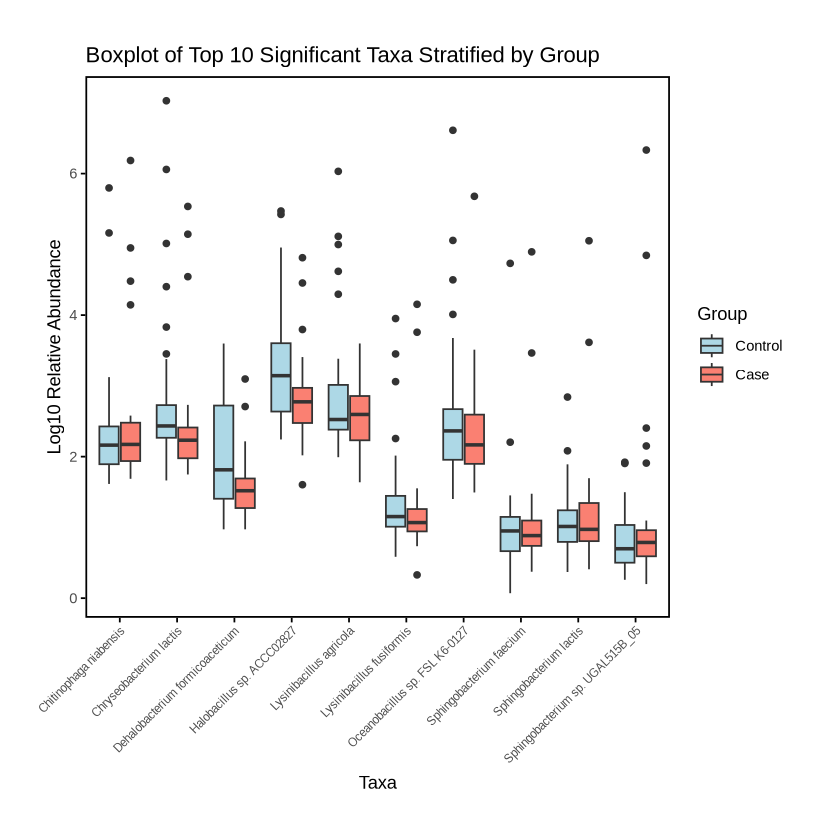

In [ ]:
# Load ggplot2 for plotting
library(ggplot2)

# Create the boxplot stratified by case and control
ggplot(top_res_with_group, aes(x = taxa_label, y = relative_abundance, fill = Group)) +
  geom_boxplot() +
  # Customize the fill color for case and control groups
  scale_fill_manual(values = c("lightblue", "salmon"), labels = c("Control", "Case")) +
  # Add plot labels and theme customization
  labs(title = "Boxplot of Top 10 Significant Taxa Stratified by Group",
       x = "Taxa",
       y = "Log10 Relative Abundance",
       fill = "Group") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),  # Remove gridlines
        panel.border = element_rect(color = "black", fill = NA, size = 1),  # Add black border
        legend.position = "right")+
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))


In [ ]:
# Load required packages
library(phyloseq)
library(reshape2)
library(dplyr)

# Step 1: Clean the Taxonomic Table
# Convert the taxonomic table to a data frame and rename columns to their taxonomic ranks
tax_table_df <- as.data.frame(tax_table(physeq_corrected_log))
colnames(tax_table_df) <- c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species")

# Remove prefixes (like "k__", "p__", etc.) from taxonomic labels
tax_table_df <- as.data.frame(lapply(tax_table_df, function(x) {
  gsub("^[a-z]__|__", "", x)  # Remove prefixes that start with a letter + '__'
}))

# Ensure OTU IDs are set as row names in the tax table data frame
tax_table_df$OTU <- rownames(tax_table_df)

# Step 2: Extract the OTU Table from Phyloseq and Transform to Data Frame
# Extract the OTU count table from phyloseq
otu_counts <- as(otu_table(physeq_corrected_log), "matrix")

# Apply log10 transformation with pseudocount (to avoid issues with zeros)
otu_counts_log <- log10(otu_counts + 1e-9)

# Convert OTU counts to a data frame
otu_counts_log_df <- as.data.frame(otu_counts_log)
otu_counts_log_df$OTU <- rownames(otu_counts_log_df)

# Convert counts to long format (melt) to facilitate merging
otu_counts_long <- melt(otu_counts_log_df, id.vars = "OTU", variable.name = "Sample", value.name = "relative_abundance")

# Step 3: Extract Sample Metadata from Phyloseq
# Convert sample data to a data frame and set Sample IDs
sample_data_df <- as(sample_data(physeq_corrected_log), "data.frame")
sample_data_df$Sample <- rownames(sample_data_df)

# Keep only the Group/Condition and Sample IDs for later merging
sample_group_df <- sample_data_df[, c("Sample", "Group", "Hypertension", "GDM")]



# Assuming your data frame is named df
sample_group_df <- sample_group_df %>%
  mutate(Condition = case_when(
    Hypertension == "Yes" ~ "Hypertension",
    GDM == "Yes" ~ "GDM",
    TRUE ~ "Healthy"  # Optional, in case both are 'no', can also use NA
  ))
head(sample_group_df)

# Step 4: Merge OTU Abundance with Sample Metadata
# Merge OTU abundance data (in long format) with sample metadata (Group info)
otu_counts_long_with_group <- merge(otu_counts_long, sample_group_df, by = "Sample", all.x = TRUE)

# Step 5: Merge with Taxonomic Table
# Merge the long-format OTU data with the taxonomic information
merged_df <- merge(otu_counts_long_with_group, tax_table_df, by = "OTU", all.x = TRUE)

# Step 6: Create Descriptive Taxa Labels
# Create a new column that combines Genus and Species for labeling
merged_df$taxa_label <- apply(merged_df[, c("Genus", "Species")], 1, function(row) {
  genus <- row["Genus"]
  species <- row["Species"]

  if (!is.na(genus) & genus != "" & !is.na(species) & species != "") {
    return(paste(genus, species, sep = " "))  # Concatenate Genus and Species
  } else if (!is.na(genus) & genus != "") {
    return(genus)  # Use Genus if Species is missing
  } else if (!is.na(species) & species != "") {
    return(species)  # Rare case where only Species is available
  } else {
    return(row["OTU"])  # Fallback to OTU ID if both are missing
  }
})

# Verify the final merged data frame
head(merged_df)


,Sample,Group,Hypertension,GDM,Condition
,<chr>,<chr>,<chr>,<chr>,<chr>
S00JD-0019,S00JD-0019,Case,No,Yes,GDM
S00JD-0015,S00JD-0015,Case,Yes,Yes,Hypertension
S00JD-0013,S00JD-0013,Case,Yes,No,Hypertension
S00NO-0023,S00NO-0023,Case,Yes,Yes,Hypertension
S00JD-0002,S00JD-0002,Case,Yes,No,Hypertension
S00JD-0001,S00JD-0001,Case,Yes,No,Hypertension


,OTU,Sample,relative_abundance,Group,Hypertension,GDM,Condition,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label
,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,10,S00JD-0003,-1.1740583,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
2,10,S00NO-0008,-1.9971245,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
3,10,S00JD-0045,-1.4175429,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
4,10,S00JD-0016,-1.3930426,Case,Yes,Yes,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
5,10,S00NO-0004,-0.9371218,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
6,10,S00JD-0024,-1.2607227,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis


,OTU,Sample,relative_abundance,Group,Hypertension,GDM,Condition,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label
,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,10,S00JD-0003,-1.1740583,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
2,10,S00NO-0008,-1.9971245,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
3,10,S00JD-0045,-1.4175429,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
4,10,S00JD-0016,-1.3930426,Case,Yes,Yes,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
5,10,S00NO-0004,-0.9371218,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
6,10,S00JD-0024,-1.2607227,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis


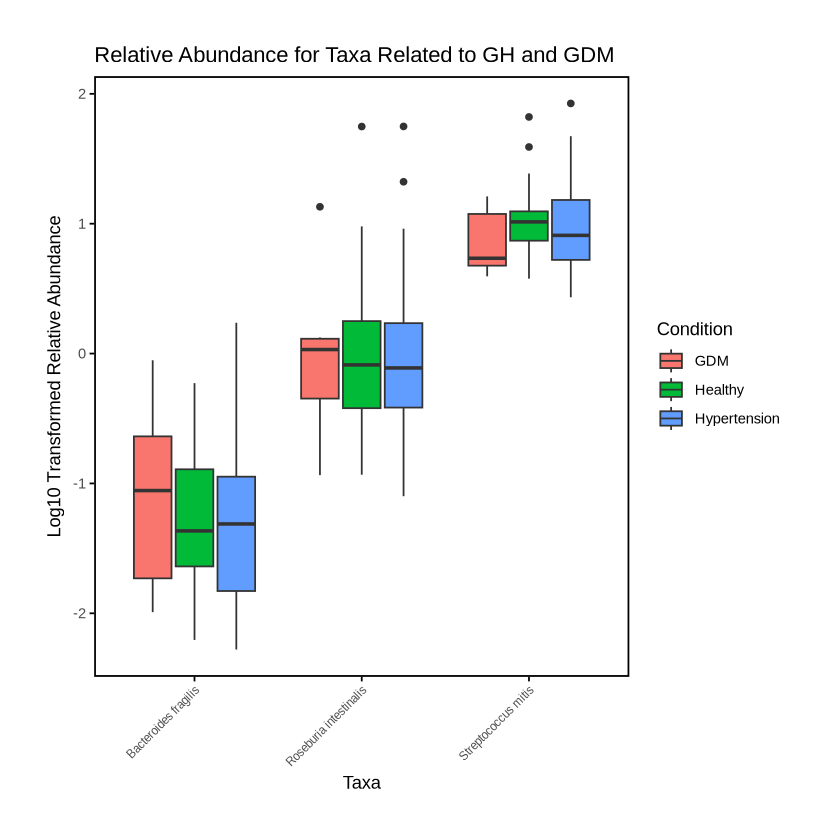

In [ ]:

# Filter the dataset for the specific taxa related to gestational hypertension and GDM
# You need to specify which taxa are related to GH and GDM based on your analysis
# For example, let's assume you are interested in the taxa named "Taxon1", "Taxon2", etc.
# Define the specific species of interest
species_gh <- c("Prevotella copri", "Clostridium difficile", "Lactobacillus reuteri", "Bacteroides fragilis", "Streptococcus mitis")
species_gdm <- c("Akkermansia muciniphila", "Bifidobacterium longum", "Ruminococcus bromii", "Roseburia intestinalis", "Escherichia coli")

# Combine all species of interest
taxa_of_interest <- c(species_gh, species_gdm)
filtered_data <- merged_df %>% filter(taxa_label %in% taxa_of_interest)

head(filtered_data)
# Create a box plot comparing relative abundance between groups (GH, GDM, Control)
ggplot(filtered_data, aes(x = taxa_label, y = relative_abundance, fill = Condition)) +
  geom_boxplot() +
  labs(title = "Relative Abundance for Taxa Related to GH and GDM",
       x = "Taxa",
       y = "Log10 Transformed Relative Abundance",
       fill = "Condition") +
theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        legend.position = "right") +
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))

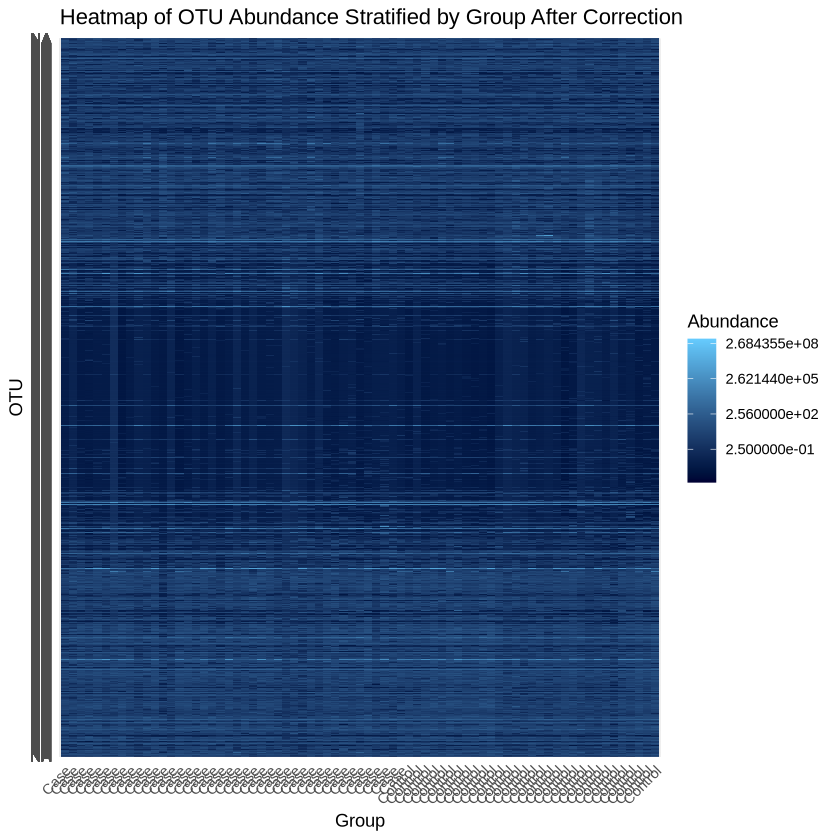

In [ ]:
plot_heatmap(physeq_corrected_log, 
             sample.label = "Group", 
             distance = "bray", 
             sample.order = "Group",
             taxa.label = "OTU") +
  ggtitle("Heatmap of OTU Abundance Stratified by Group After Correction") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [ ]:
library(tidyr)

# Remove rows with NA in any taxa-related columns (Phylum, Class, Order, Family, Genus, Species)
df_cleaned <- merged_df %>%
  drop_na(Phylum, Class, Order, Family, Genus, Species)

# Check the cleaned data
head(df_cleaned)




Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following object is masked from ‘package:S4Vectors’:

    expand




,OTU,Sample,relative_abundance,Group,Hypertension,GDM,Condition,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label
,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,10,S00JD-0003,-1.1740583,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
2,10,S00NO-0008,-1.9971245,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
3,10,S00JD-0045,-1.4175429,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
4,10,S00JD-0016,-1.3930426,Case,Yes,Yes,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
5,10,S00NO-0004,-0.9371218,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
6,10,S00JD-0024,-1.2607227,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis


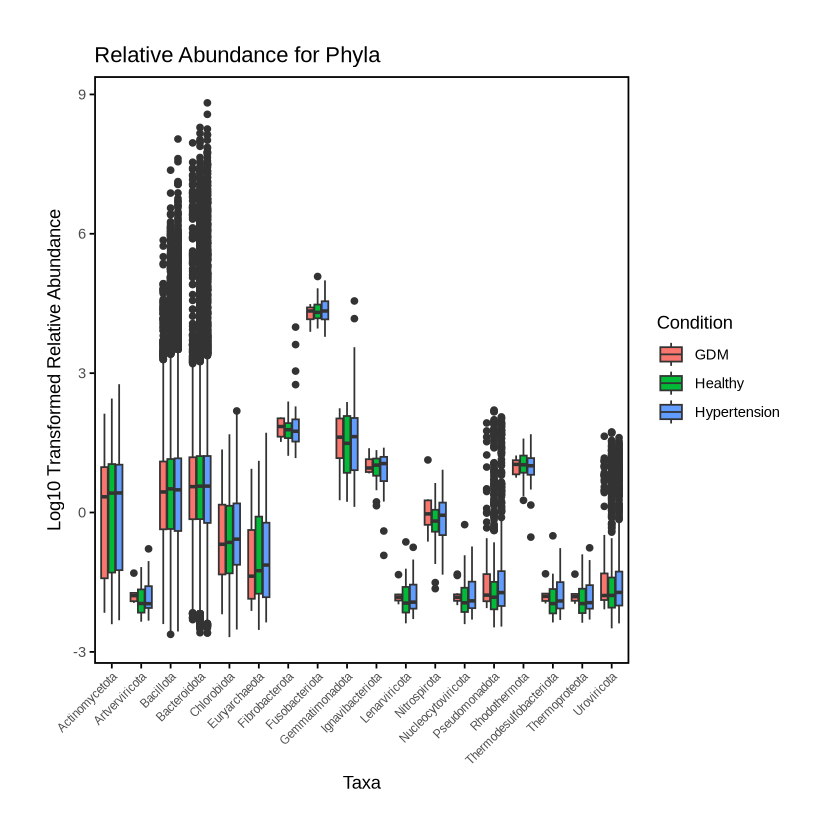

In [ ]:


# Create a box plot comparing relative abundance between groups (GH, GDM, Control)
ggplot(df_cleaned, aes(x = Phylum, y = relative_abundance, fill = Condition)) +
  geom_boxplot() +
  labs(title = "Relative Abundance for Phyla",
       x = "Taxa",
       y = "Log10 Transformed Relative Abundance",
       fill = "Condition") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        legend.position = "right") +
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))


In [ ]:
head(merged_df)
df <- merged_df

,OTU,Sample,relative_abundance,Group,Hypertension,GDM,Condition,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label
,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,10,S00JD-0003,-1.1740583,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
2,10,S00NO-0008,-1.9971245,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
3,10,S00JD-0045,-1.4175429,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
4,10,S00JD-0016,-1.3930426,Case,Yes,Yes,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
5,10,S00NO-0004,-0.9371218,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis
6,10,S00JD-0024,-1.2607227,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis


Sample,Bacillota,Bacteroidota
<fct>,<dbl>,<dbl>
S00JD-0019,222.6066,260.6704
S00JD-0015,311.0077,287.7487
S00JD-0013,268.4316,230.8734
S00NO-0023,279.6398,263.4920
S00JD-0002,229.0586,231.5355
S00JD-0001,259.5317,261.5249


Sample,Bacillota,Bacteroidota,FB_Ratio
<fct>,<dbl>,<dbl>,<dbl>
S00JD-0019,222.6066,260.6704,0.8539773
S00JD-0015,311.0077,287.7487,1.0808310
S00JD-0013,268.4316,230.8734,1.1626787
S00NO-0023,279.6398,263.4920,1.0612837
S00JD-0002,229.0586,231.5355,0.9893024
S00JD-0001,259.5317,261.5249,0.9923786


,OTU,Sample,relative_abundance,Group,Hypertension,GDM,Condition,Kingdom,Phylum,Class,Order,Family,Genus,Species,taxa_label,FB_Ratio
,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,10,S00JD-0003,-1.1740583,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,0.9245277
2,10,S00NO-0008,-1.9971245,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,1.0467765
3,10,S00JD-0045,-1.4175429,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,0.9378311
4,10,S00JD-0016,-1.3930426,Case,Yes,Yes,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,1.0073530
5,10,S00NO-0004,-0.9371218,Control,No,No,Healthy,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,0.9026491
6,10,S00JD-0024,-1.2607227,Case,Yes,No,Hypertension,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,fragilis,Bacteroides fragilis,1.2285482


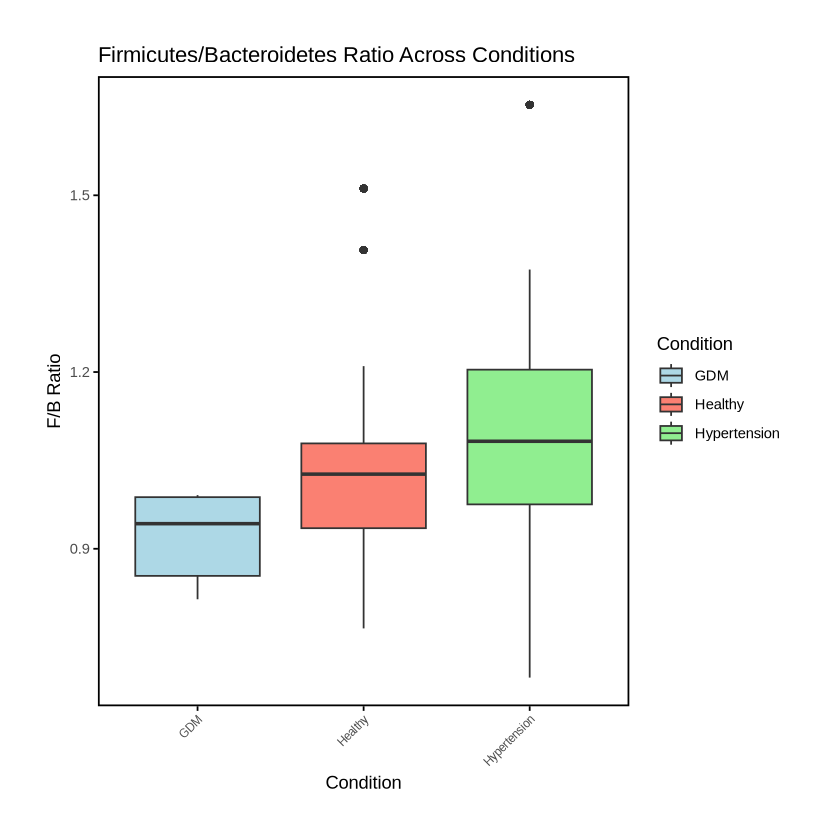

In [ ]:
# Load necessary library
library(dplyr)

# Filter the data for Firmicutes and Bacteroidetes
fb_data <- df %>%
  filter(Phylum %in% c("Bacillota", "Bacteroidota"))

# Aggregate data to calculate total abundance of Firmicutes and Bacteroidetes for each sample
fb_agg <- fb_data %>%
  group_by(Sample, Phylum) %>%
  summarise(Total_Abundance = sum(relative_abundance, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = Phylum, values_from = Total_Abundance, values_fill = list(Total_Abundance = 0))

# Check the aggregated data
head(fb_agg)

# Calculate F/B ratio
fb_agg <- fb_agg %>%
  mutate(FB_Ratio = ifelse(Bacteroidota > 0, Bacillota/ Bacteroidota, NA))

# Check the updated data with FB ratio
head(fb_agg)

# Merge the FB ratio with the original dataframe
df_with_fb <- df %>%
  left_join(fb_agg %>% select(Sample, FB_Ratio), by = "Sample")

# Check the updated dataframe
head(df_with_fb)

# Create a boxplot of the Firmicutes/Bacteroidetes ratio across different conditions
ggplot(df_with_fb, aes(x = Condition, y = FB_Ratio, fill = Condition)) +
  geom_boxplot() +
  scale_fill_manual(values = c("lightblue", "salmon", "lightgreen"))+
  # Add plot labels and theme customization
  labs(title = "Firmicutes/Bacteroidetes Ratio Across Conditions",
       x = "Condition",
       y = "F/B Ratio",
       fill = "Condition") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        legend.position = "right") +
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))


Condition,Phylum,Total_Abundance
<chr>,<chr>,<dbl>
GDM,Actinomycetota,-8.318927
GDM,Artverviricota,-10.486460
GDM,Bacillota,1431.051352
GDM,Bacteroidota,1548.746853
GDM,Chlorobiota,-40.136666
GDM,Euryarchaeota,-25.114487


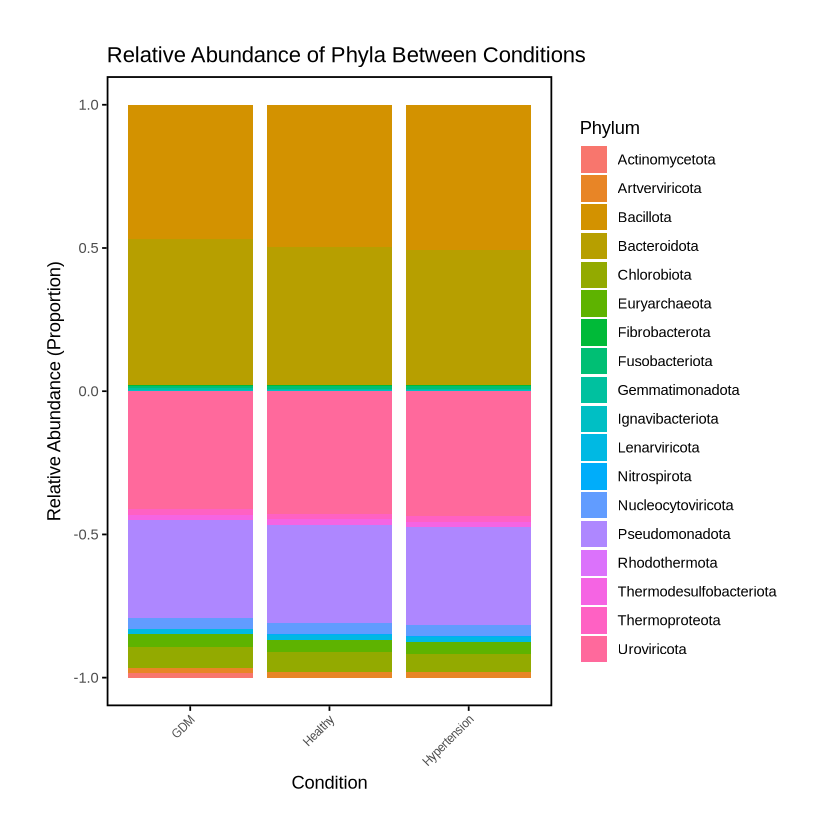

In [ ]:
# Load necessary libraries
library(dplyr)
library(tidyr)

# Aggregate data by Condition and Phylum
agg_data <- df_cleaned %>%
  group_by(Condition, Phylum) %>%
  summarise(Total_Abundance = sum(relative_abundance, na.rm = TRUE), .groups = "drop")

# Check the aggregated data
head(agg_data)
# Load ggplot2 for plotting
library(ggplot2)

# Create the stacked barplot
ggplot(agg_data, aes(x = Condition, y = Total_Abundance, fill = Phylum)) +
  geom_bar(stat = "identity", position = "fill") +
  # Customize the plot
  labs(title = "Relative Abundance of Phyla Between Conditions",
       x = "Condition",
       y = "Relative Abundance (Proportion)",
       fill = "Phylum") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, size = 1),
        axis.ticks.x = element_line(color = "black", size = 0.5),
        axis.ticks.y = element_line(color = "black", size = 0.5),
        legend.position = "right") +
  theme(plot.margin = margin(1, 1, 1, 1, "cm"))
